In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import StandardScaler

In [2]:
def plot_metric(modelIn, metric):
    train_metrics = modelIn.history[metric]
    val_metrics = modelIn.history['val_'+metric]
    epochs = range(1, len(train_metrics) + 1)
    plt.plot(epochs, train_metrics)
    plt.plot(epochs, val_metrics)
    plt.title('Training and validation '+ metric)
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend(["train_"+metric, 'val_'+metric])
    plt.show()

In [3]:
df = pd.read_csv('G:\My Drive\Course Info\Classes\Graduate ML course\Projects\Project1Data.csv')
df

,Unnamed: 0,a,b,c,d,e,f,g,h,i,...,T,U,V,W,X,Y,Z,outputEZ,outputDifficult,outputUNFAIR
0,0,1.017164,0.910404,-0.658568,-0.077294,-0.686616,-1.283178,-1.287985,0.069590,-1.450902,...,-0.261135,0.267992,-0.389373,-0.680021,0.080972,0.042742,0.859960,1.409385,0.386792,0.519694
1,1,0.315715,-1.278216,0.235165,1.154491,1.037710,-0.058347,-1.001977,-1.088151,1.317426,...,-0.265034,-1.342382,0.340043,-0.542528,-2.515714,0.482028,0.781699,1.180672,-0.969939,-0.262854
2,2,-1.170508,1.835963,1.344854,-0.585624,0.917561,-1.611192,-0.604699,1.946328,1.401165,...,0.166792,0.277791,-0.443603,0.894382,1.273769,-0.380353,-0.181673,-0.326711,1.955889,0.707869
3,3,0.106433,-1.310156,-0.531846,-0.496501,-0.686423,0.328594,-0.391220,-1.072117,-0.368390,...,2.008463,1.002400,0.201159,-0.640438,0.823335,2.404282,-1.155632,0.575793,-0.830786,-0.230814
4,4,-1.001568,1.121767,0.783623,-1.229862,-1.576483,1.210852,0.405381,0.910166,0.120625,...,-1.218032,-1.597016,-0.536410,-1.052742,0.449455,-0.204451,1.029519,-1.682639,0.693671,-0.270661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,-0.486577,0.230604,0.774568,-0.895015,1.180721,-0.887009,-0.672307,1.473336,-1.582988,...,0.713244,-0.123491,0.545237,-0.569980,-1.977632,0.943541,-0.297903,0.024607,-1.096600,-0.149142
9996,9996,-0.090722,-1.776910,1.010701,1.131752,-0.280139,0.328043,-1.022805,0.410038,-0.198526,...,0.669713,2.569278,-0.525292,0.970375,1.432950,-2.105378,0.410211,-0.882419,0.561321,-0.699103
9997,9997,-1.179489,-2.133074,0.609792,0.867964,-1.214933,-1.066639,0.340836,-0.046780,0.864131,...,2.335723,1.095632,-1.356358,0.601345,0.438655,-0.739430,-1.281991,-0.717864,0.080827,-0.049389
9998,9998,-1.081154,0.409963,1.885867,-0.509416,1.229244,0.956967,-0.653818,-0.715568,0.650751,...,0.292099,1.617503,-0.168090,-2.306492,-0.199175,-0.679085,-0.296944,-0.832492,2.626280,-1.074615


In [4]:
X_train = df.iloc[1:7000, :52]
y_train = df[['outputUNFAIR']][1:7000]
X_test = df.iloc[7001:, :52]
y_test = df[['outputUNFAIR']][7001:]

In [10]:
## Define the model architecture
model = models.Sequential()

model.add(layers.Input(shape = (52,))) #No activiation, this is the input layer
model.add(layers.Dense(3, activation='relu'))
model.add(layers.Dense(3, activation='relu')) 
model.add(layers.Dense(3, activation='relu')) 
model.add(layers.Dense(3, activation='relu')) 

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3)              │           159 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195 (780.00 B)

 Trainable params: 195 (780.00 B)

 Non-trainable params: 0 (0.00 B)

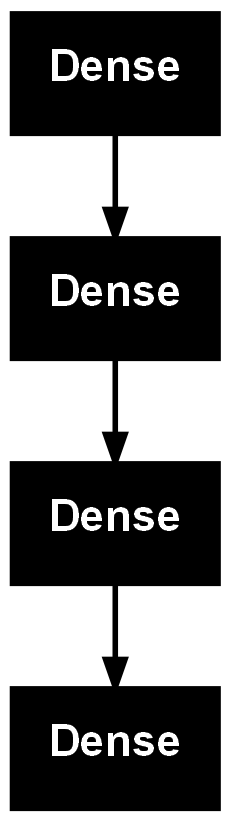

In [12]:
plot_model(model)

In [13]:
modelFitted = model.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3533.6697 - val_loss: 688.4664
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 75.6508 - val_loss: 8.8740
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7917 - val_loss: 0.9264
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1569 - val_loss: 0.8999
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9877 - val_loss: 0.8970
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9686 - val_loss: 0.8963
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0191 - val_loss: 0.8960
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0168 - val_loss: 0.8959
Epoch 9/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0910 - val_loss: 0.8957
Epoch 10/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0552 - val_loss: 0.8956


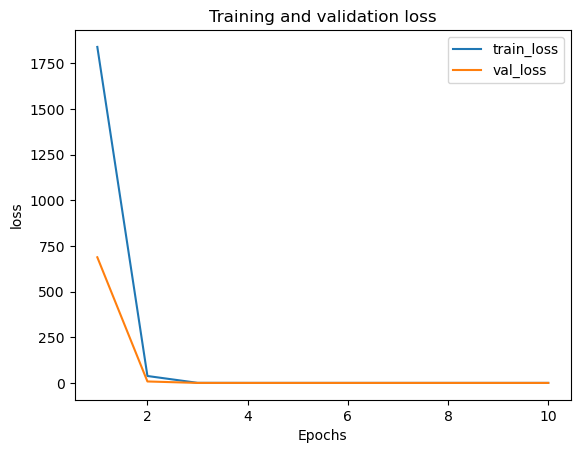

In [14]:
plot_metric(modelFitted, "loss")